In [1]:
import os
import sys
import torch
import logging
import argparse
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

current_dir = os.path.dirname(os.path.abspath(""))
src_dir = os.path.join(current_dir, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from hawkes import models, utils
from hawkes.utils import config, plotting

In [2]:
# Load relevant data

seq = torch.load("outputs/data/events.pt", weights_only=False)
model_sim = torch.load("outputs/data/model_sim.pt", weights_only=False)
model_est = torch.load("outputs/data/model_est.pt", weights_only=False)

In [3]:
# Anderson-Darling and Kolmogorov-Smirnov tests

states = model_est.intensity_states(seq)
rescaled_times = model_est.rescaled_times(seq, states)
tau = rescaled_times.sum(dim=1).detach().cpu().numpy()

print("Summary:")
print(tau.mean(), tau.std())
print(np.min(tau), np.max(tau))
print()

result = sp.stats.anderson(tau.clip(1e-10), dist="expon")
print("Anderson-Darling statistic: ", result.statistic)
print("Reject:")
for val, res in zip(
    result.statistic > result.critical_values, result.significance_level
):
    print(f"  {res}%: {val}")
print()

result = sp.stats.kstest(tau, "expon")
print("Kolmogorov-Smirnov statistic: ", result.statistic)
print("p-value: ", result.pvalue)
print("Reject: ", result.pvalue < 0.05)

Summary:
0.9875392 0.9886828
0.0 13.856676

Anderson-Darling statistic:  0.6071620119346335
Reject:
  15.0%: False
  10.0%: False
  5.0%: False
  2.5%: False
  1.0%: False

Kolmogorov-Smirnov statistic:  0.006774794145063323
p-value:  0.7456810589266951
Reject:  False


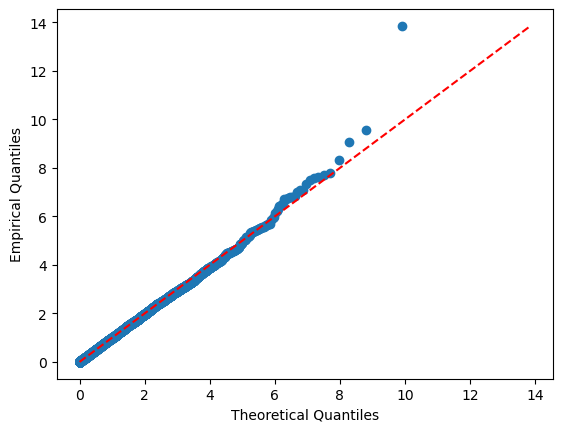

In [4]:
# Q-Q plot versus Exp(1)

tau_sorted = np.sort(tau)

n = len(tau_sorted)
p = (np.arange(1, n + 1) - 0.5) / n

theoretical_quantiles = -np.log(1 - p)

plt.plot(theoretical_quantiles, tau_sorted, "o")
plt.plot(
    [0, max(theoretical_quantiles.max(), tau_sorted.max())],
    [0, max(theoretical_quantiles.max(), tau_sorted.max())],
    linestyle="--",
    color="red",
)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Empirical Quantiles")
plt.show()